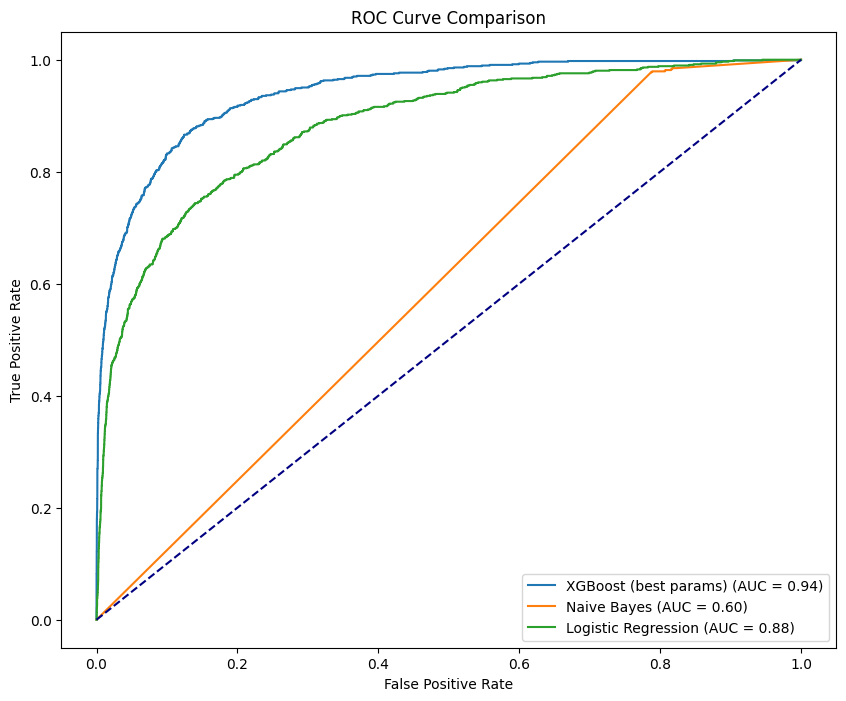

In [6]:
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, GridSearchCV, train_test_split
from sklearn.metrics import roc_curve, roc_auc_score, auc
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Cargar los datos
data = pd.read_csv('hoteles-entrena-limpio-normalizado.csv')
X = data.drop(columns=['children'])
y = data['children']

# Dividir datos para entrenar y validar
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Definir el modelo de XGBoost con GridSearch y L2 Regularization (lambda)
xgb_model = XGBClassifier(objective='binary:logistic', eval_metric='logloss')
param_grid = {
    'lambda': [0.1, 1, 10],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'n_estimators': [50, 100, 200]
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_search = GridSearchCV(xgb_model, param_grid, scoring='neg_log_loss', cv=cv)
grid_search.fit(X_train, y_train)
best_xgb = grid_search.best_estimator_

# Modelo Naive Bayes
naive_model = GaussianNB()
naive_model.fit(X_train, y_train)

# Modelo de Regresión Logística
log_reg_model = Pipeline([
    ('scaler', StandardScaler()),
    ('log_reg', LogisticRegression(max_iter=1000, solver='lbfgs'))
])

log_reg_model.fit(X_train, y_train)

# Predicciones y puntuaciones de AUC
models = {
    'XGBoost (best params)': best_xgb,
    'Naive Bayes': naive_model,
    'Logistic Regression': log_reg_model
}

plt.figure(figsize=(10, 8))
for model_name, model in models.items():
    y_val_proba = model.predict_proba(X_val)[:, 1]
    fpr, tpr, _ = roc_curve(y_val, y_val_proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {roc_auc:.2f})')

# Configurar gráfica ROC
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc='lower right')
plt.show()

In [7]:
from sklearn.metrics import accuracy_score, log_loss, roc_auc_score, classification_report

# Predecir en el conjunto de prueba con el mejor modelo de XGBoost
y_pred_xgb = best_xgb.predict(X_val)
y_pred_proba_xgb = best_xgb.predict_proba(X_val)[:, 1]

# Calcular métricas para XGBoost
accuracy_xgb = accuracy_score(y_val, y_pred_xgb)
logloss_xgb = log_loss(y_val, y_pred_proba_xgb)
auc_xgb = roc_auc_score(y_val, y_pred_proba_xgb)

# Mostrar resultados
print("Resultados del modelo optimizado de XGBoost en el conjunto de prueba:")
print(f"Accuracy: {accuracy_xgb:.4f}")
print(f"Log Loss: {logloss_xgb:.4f}")
print(f"AUC: {auc_xgb:.4f}")
print(classification_report(y_val, y_pred_xgb))

Resultados del modelo optimizado de XGBoost en el conjunto de prueba:
Accuracy: 0.9501
Log Loss: 0.1390
AUC: 0.9424
              precision    recall  f1-score   support

           0       0.96      0.99      0.97      9730
           1       0.82      0.50      0.62       867

    accuracy                           0.95     10597
   macro avg       0.89      0.75      0.80     10597
weighted avg       0.95      0.95      0.94     10597



In [9]:
import pandas as pd
from datetime import datetime

# Cargar el archivo de prueba
test_data = pd.read_csv('hoteles-prueba-limpio-normalizado.csv')

# Extraer la columna "id" y preparar los datos para predicción
test_ids = test_data['id']
X_test_data = test_data.drop(columns=['id'])

# Generar las probabilidades de predicción usando el mejor modelo de XGBoost
y_pred_proba_test = best_xgb.predict_proba(X_test_data)[:, 1]

# Crear el archivo con timestamp
timestamp = datetime.now().strftime("%Y_%m_%d_%H_%M")
file_name = f'kaggle_submission_{timestamp}.csv'
kaggle_submission = pd.DataFrame({'id': test_ids, 'prob': y_pred_proba_test})

# Guardar el archivo para Kaggle
kaggle_submission.to_csv(file_name, index=False)

print(f"Archivo '{file_name}' creado con éxito para Kaggle.")

Archivo 'kaggle_submission_2024_10_13_12_25.csv' creado con éxito para Kaggle.
